In [750]:
from operator import truediv

import pandas as pd
import numpy as np
from pathlib import Path
base_path = Path(r"C:\Users\misia\PycharmProjects\ml-wakacyjne-wyzwanie-2026\01_przetwarzanie_wizualizacja_danych")


# Analiza i przetwarzanie danych na temat Titanica

#### Wyobraź sobie, że pewnego wakacyjnego dnia, będąc na plaży w pełnym słońcu, odbierasz telefon od nieznanego numeru.
Robisz to niechętnie — zasłużyłeś/aś przecież na odpoczynek i chcesz mieć ten czas tylko dla siebie. Już masz na końcu języka wymijającą odpowiedź, gdy nagle z drugiej strony słyszysz:
„Czy jesteś gotowy, by tego lata rozwikłać jedną z największych zagadek ludzkości?”

Jako osoba z natury ciekawa świata i ze świetnym umysłem analitycznym, szybko zapominasz o plaży i wakacjach. Zaintrygowany/a dopytujesz o szczegóły, ale rozmówca nie chce zdradzić zbyt wiele. Wiadomo jedynie, że chodzi o *zatonięcie Titanica w 1914* roku, a celem misji jest ustalenie, które osoby miały szansę przeżyć.

**Ty** — jako **renomowany analityk danych** — byłeś/byłaś ich pierwszym wyborem do analizy i oczyszczenia danych. Mimo wątpliwości postanawiasz podjąć się zadania, mając nadzieję, że twoja wiedza może zostać praktycznie wykorzystana w słusznym celu.


#### Twoim celem będzie przeanalizowanie i przetworzenie zbioru danych w taki sposób, by mógł on być użyty do nauki modelu do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

(Uwaga: w tym zadaniu nie będziesz trenować modeli, ta przyjemność spotka cię w następnych notebookach)

Poniżej znajdziesz pytania, które mogą być pomocne w analizie, oraz odwołania do poszczególnych sekcji z notebooka do lekcji:

- Czy wszystkie kolumny są istotne w kontekście zadania?
- Czy występują brakujące wartości? Jeśli tak, to jak je uzupełnisz? (sekcja #2.1)
- Czy typy danych są odpowiednie do znaczenia kolumny? (sekcja #1.3)
- Czy dystrybucje danych mają rozkłady normalne, czy asymetryczne? (sekcja #4.1 + wykład)
- Która zmienna oznacza predykowaną klasę?
- Jaki jest rozkład zmiennej predykowanej względem zmiennych kategorialnych, jak i numerycznych? (sekcja #4.1)
- Czy końcowe rozkłady zawierają wartości skrajne? (sekcja #4.2 + wykład)

Wymagania:

- Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)
- Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)
- Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)
- Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych
- Każda cecha powinna być zwizualizowana co najmniej raz. Sam(a) zastanów się, czy warto wizualizować cechy parami w celu odkrycia zależności między nimi (sekcja #4.4)
- Nie ma ograniczenia na liczbę komórek, ale zastanów się, czy dana wizualizacja/obliczenie jest przydatne w całej analizie, czy po prostu sobie "egzystuje" bez żadnych wniosków

Zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Poniżej zamieszczamy tabelę z wyjaśnieniem poszczególnych kolumn:

| Kolumna      | Opis                                                                            |
| ------------ | ------------------------------------------------------------------------------- |
| **Survived** | Czy pasażer przeżył (0 = nie, 1 = tak).                                         |
| **Pclass**   | Klasa podróży (1 = I klasa, 2 = II klasa, 3 = III klasa).                       |
| **Name**     | Imię i nazwisko pasażera.                                                       |
| **Sex**      | Płeć pasażera (male = mężczyzna, female = kobieta).                             |
| **Age**      | Wiek pasażera w latach.                                                         |
| **SibSp**    | Liczba rodzeństwa i małżonków na pokładzie.                                     |
| **Parch**    | Liczba rodziców i dzieci na pokładzie.                                          |
| **Ticket**   | Numer biletu.                                                                   |
| **Fare**     | Cena biletu.                                                                    |
| **Cabin**    | Numer kabiny pasażera                                     |
| **Embarked** | Port, w którym pasażer wsiadł (C = Cherbourg, Q = Queenstown, S = Southampton). |
                                                         |


## Opracowanie danych

In [751]:
df = pd.read_csv('titanic.csv')
titanic_df = pd.read_csv('titanic.csv')

print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


### Tworzenie DataFrame

In [752]:
df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [753]:
df.Survived.value_counts(normalize=True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

### Zbiór musi być oczyszczony, tj. finalnie nie powinien mieć brakujących wartości (sekcja #2.1)

In [754]:
#sprawdzanie, czy i w jakich kolumnach brakuje danych
df.isna().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare         98
Cabin       687
Embarked      2
dtype: int64

In [755]:
#funkcja liczenia proporcji
def get_column_distribution(df, column):
  return df[column].value_counts(normalize=True)

In [756]:
#Age - uzupełnienie pustych wartosci wg prawdopodobienstwa wystąpienia
age_count_prob = get_column_distribution(df, 'Age')
age_count_prob

age_values=age_count_prob.index
age_probs=age_count_prob.values

missing_age_vals=df.Age.isna()
df.loc[missing_age_vals, 'Age']=np.random.choice(age_values, size=missing_age_vals.sum(), p=age_probs)

In [757]:
#Fare - uzupełnienie pustych wartosci wg prawdopodobienstwa wystąpienia
fare_count_prob = get_column_distribution(df, 'Fare')
fare_count_prob

fare_values=fare_count_prob.index
fare_probs=fare_count_prob.values

missing_fare_vals=df.Fare.isna()
df.loc[missing_fare_vals, 'Fare']=np.random.choice(fare_values, size=missing_fare_vals.sum(), p=fare_probs)

In [758]:
#Cabin - uzupełnienie pustych wartosci wg prawdopodobienstwa wystąpienia, wyciąganie z Cabin pierwszej litery(bardziej przydatna)
df['Cabin'].str[0].unique()
df['Cabin'] = df['Cabin'].str[0]

cabin_count_prob = get_column_distribution(df, 'Cabin')
cabin_count_prob

cabin_values=cabin_count_prob.index
cabin_probs=cabin_count_prob.values

missing_cabin_vals=df.Cabin.isna()
df.loc[missing_cabin_vals, 'Cabin']=np.random.choice(cabin_values, size=missing_cabin_vals.sum(), p=cabin_probs)

In [759]:
#Embarked - sprawdzenie, czy jedna wartość dominuje
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [760]:
#Embarked - uzupełnienie pustych wartosci medianą, bo jedna wartość dominuje
df['Embarked'].value_counts()
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [761]:
df.isna().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

### Zbiór musi zawierać co najmniej dwie dodatkowe kolumny, które mogą wzbogacić informacje zawarte w zbiorze (sekcje #1.5 i #2.2)

In [762]:
#Czy wszystkie kolumny są istotne w kontekście zadania?
#wyciąganie Title z niepotrzebnego Name
df['Name'] = df['Name'].str.extract(r',([^.]*)\.')
df=df.rename(columns={'Name':'Title'})
#usuwanie kolumny Ticket, jest niepotrzebna do analizy
df = df.drop(columns=['Ticket'])

In [763]:
#nowa kolumna Alone - jeśli podróż samemu True, w przeciwnym razie False
df['Alone'] = (df['SibSp'] + df['Parch'])
df['Alone'] = df['Alone'].apply(lambda x: True if x == 0 else False)

In [764]:
#nowa kolumna Family - SibSp + Parch
df['Family'] = df['SibSp'] + df['Parch']

In [765]:
print(df.head())

             Survived  Pclass  Title     Sex   Age  SibSp  Parch     Fare  \
PassengerId                                                                 
1                   0       3     Mr    male  22.0      1      0   7.2500   
2                   1       1    Mrs  female  38.0      1      0  71.2833   
3                   1       3   Miss  female  26.0      0      0   7.9250   
4                   1       1    Mrs  female  35.0      1      0  53.1000   
5                   0       3     Mr    male  35.0      0      0   8.0500   

            Cabin Embarked  Alone  Family  
PassengerId                                
1               E        S  False       1  
2               C        C  False       1  
3               E        S   True       0  
4               C        S  False       1  
5               D        S   True       0  


### Cechy kategorialne powinny być zakodowane, postaraj się dobrać odpowiedni sposób (sekcja #2.3)


In [766]:
df['Alone'] = df['Alone'].apply(lambda x: True if x == 0 else False)

### Zbadaj, czy występują skrajne wartości (outliery) zarówno dla wartości numerycznych, jak i dla kategorialnych

In [767]:
import matplotlib.pyplot as plt
import seaborn as sns

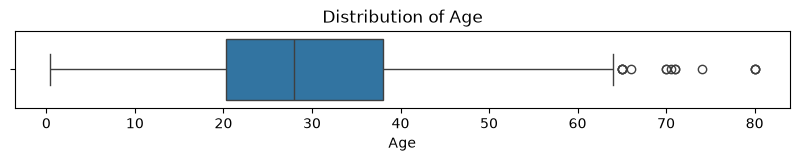

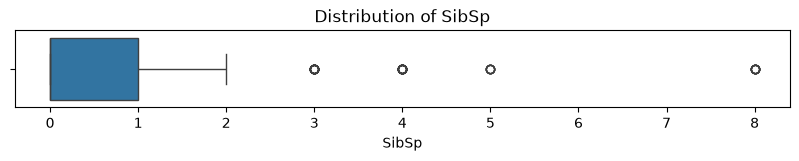

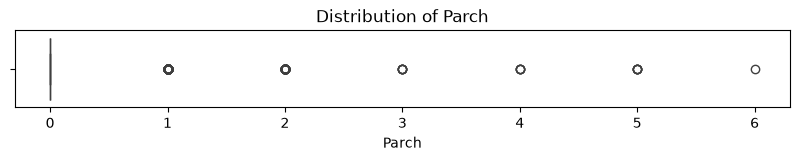

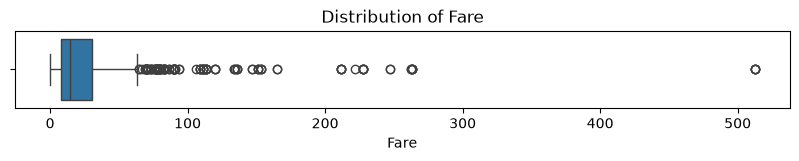

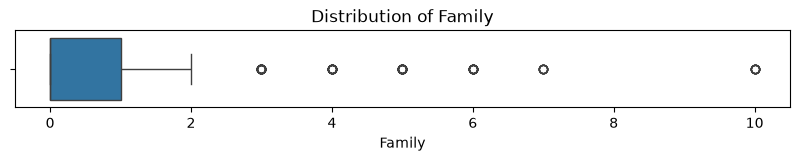

In [768]:
numeric = ['Age', 'SibSp', 'Parch', 'Fare', 'Family']
for column in numeric:
    plt.figure(figsize=(10,1))
    sns.boxplot(x=df[column])
    plt.title(f"Distribution of {column}")
    plt.show()

Są wartości skrajne, ale możliwe

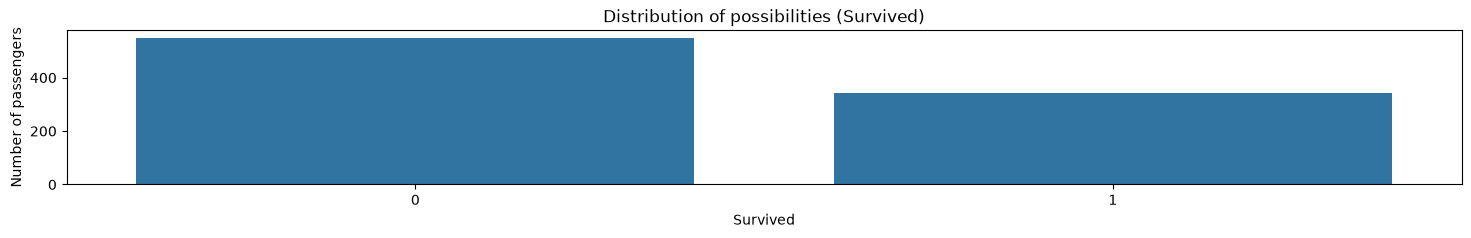

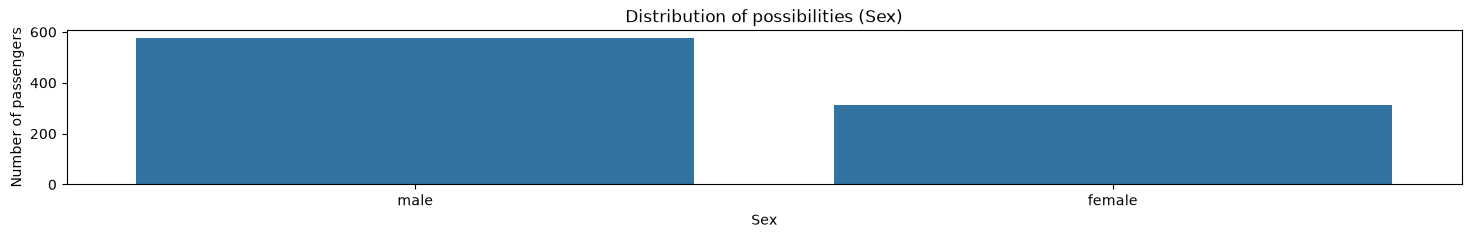

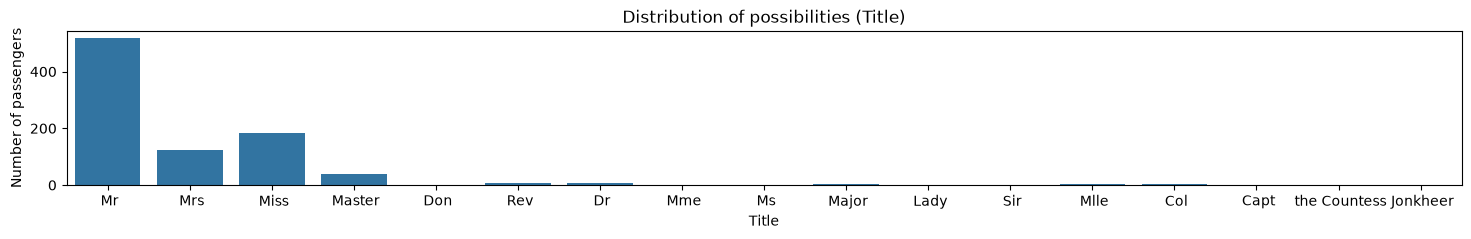

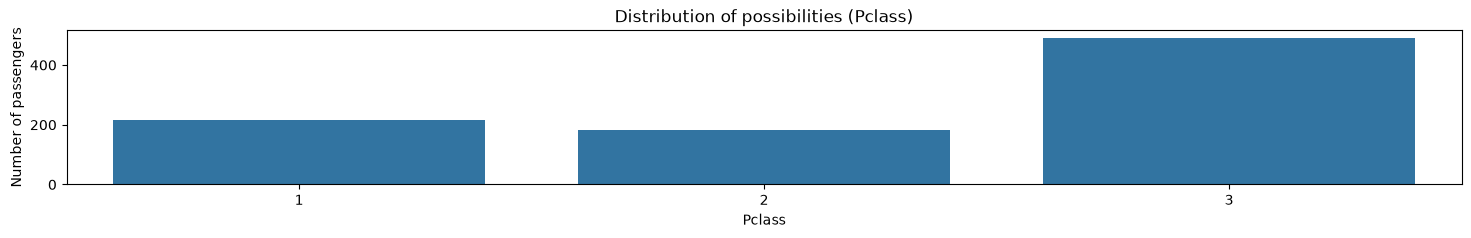

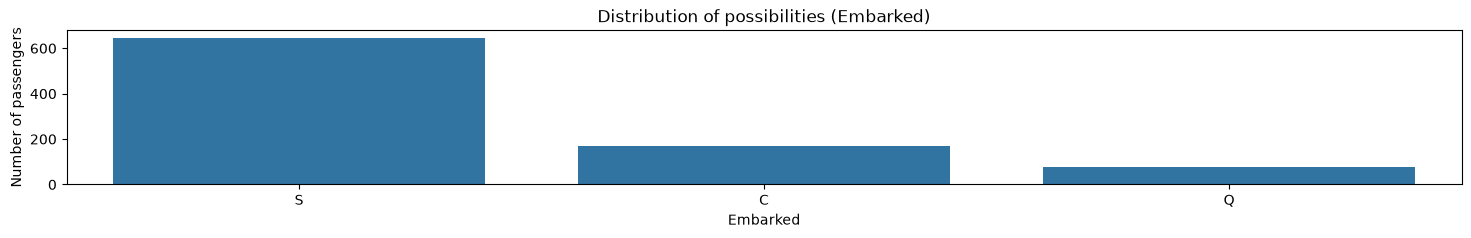

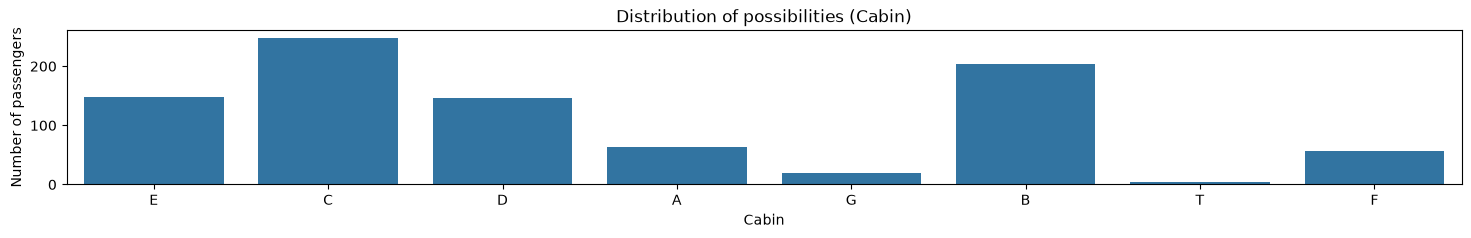

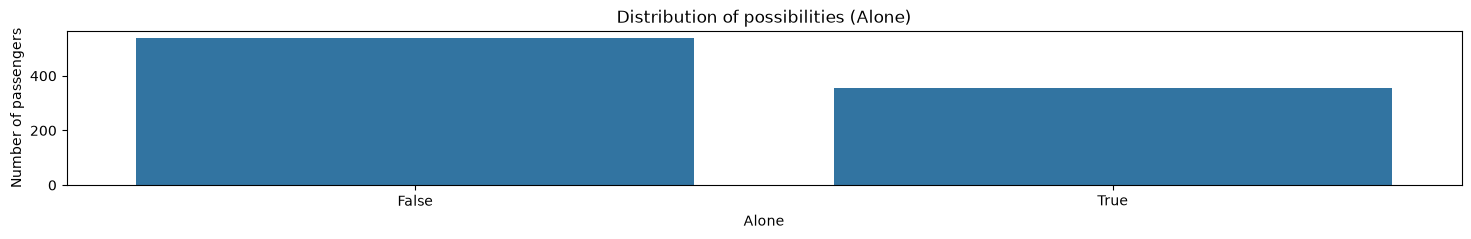

In [769]:
categorical=['Survived', 'Sex', 'Title', 'Pclass', 'Embarked', 'Cabin', 'Alone']

for column in categorical:
    plt.figure(figsize=(18,2))
    sns.countplot(data=df, x=column,)
    plt.title(f"Distribution of possibilities ({column})")
    plt.ylabel('Number of passengers')
    plt.show()

### Rozkłady przeżycia

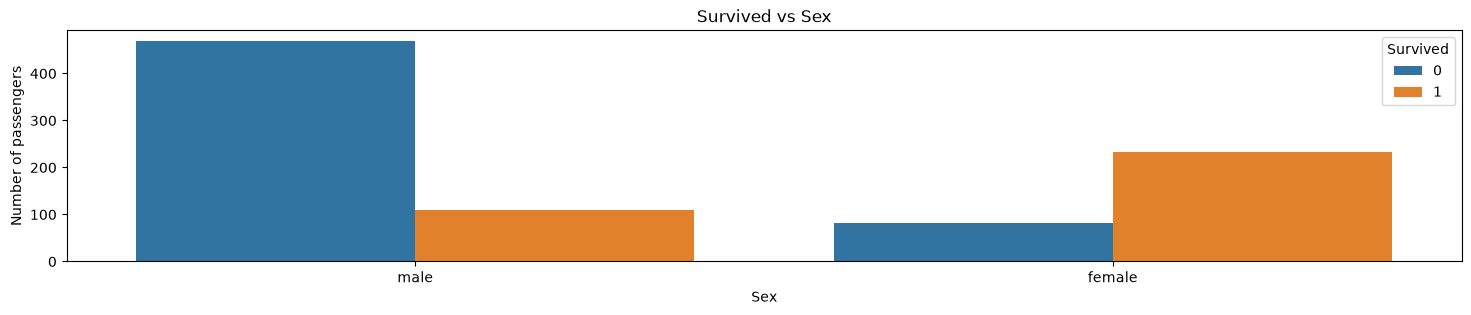

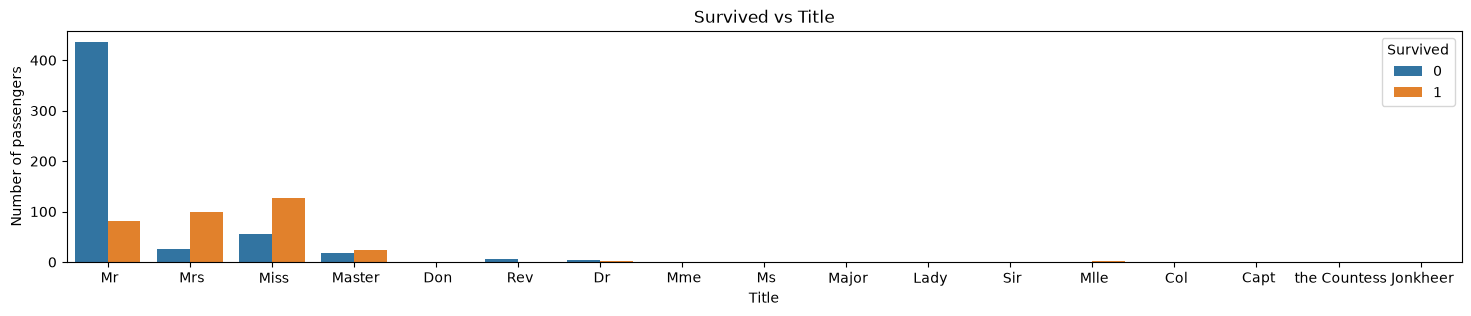

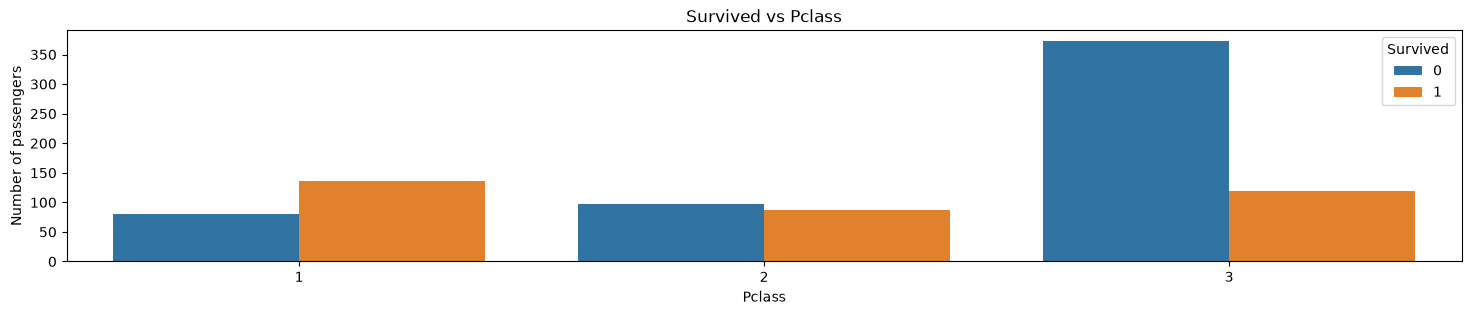

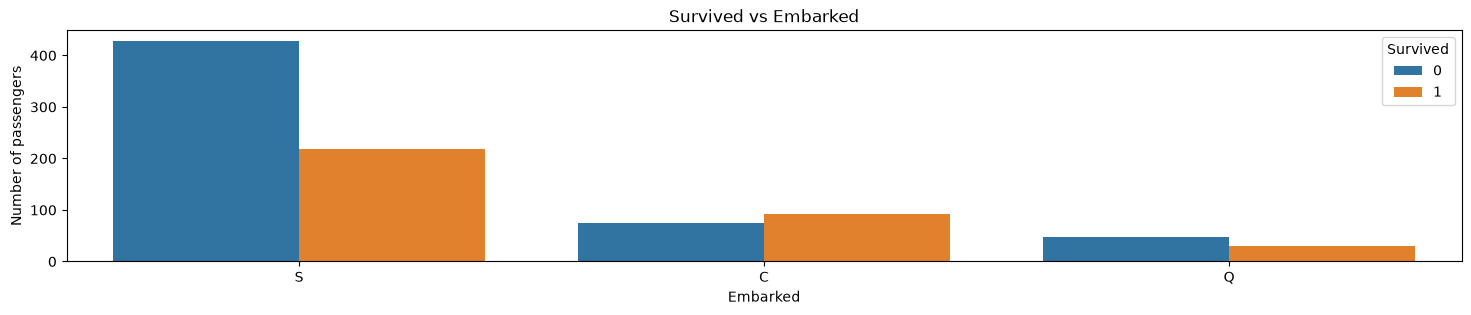

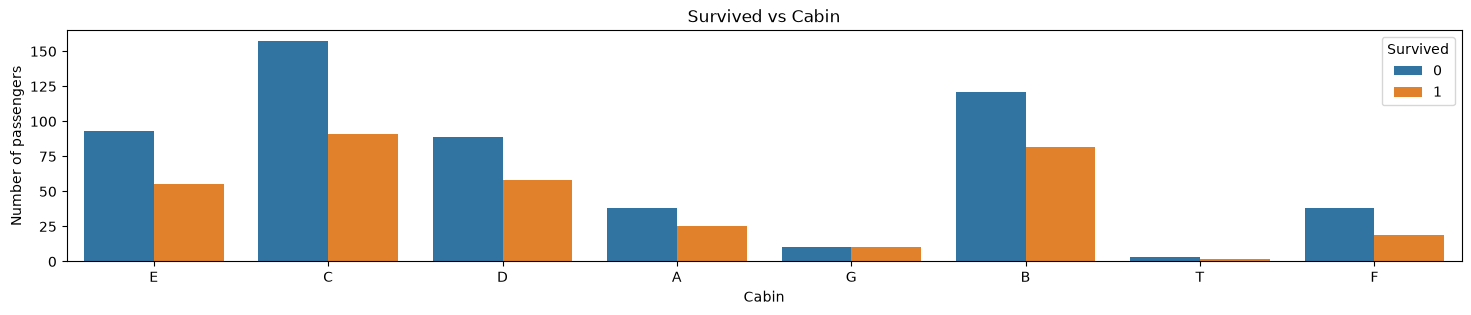

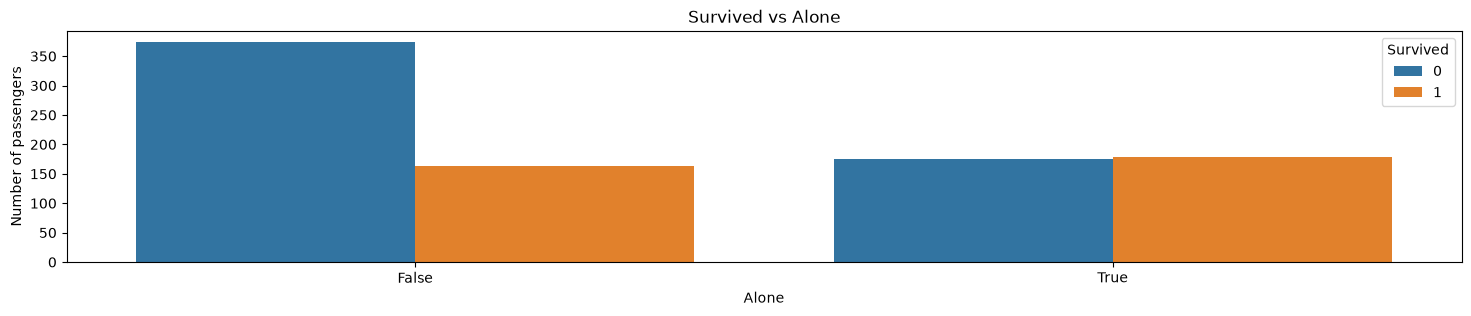

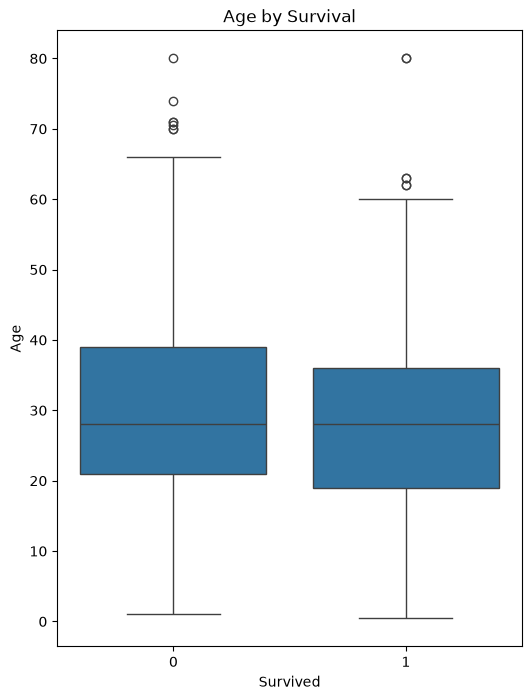

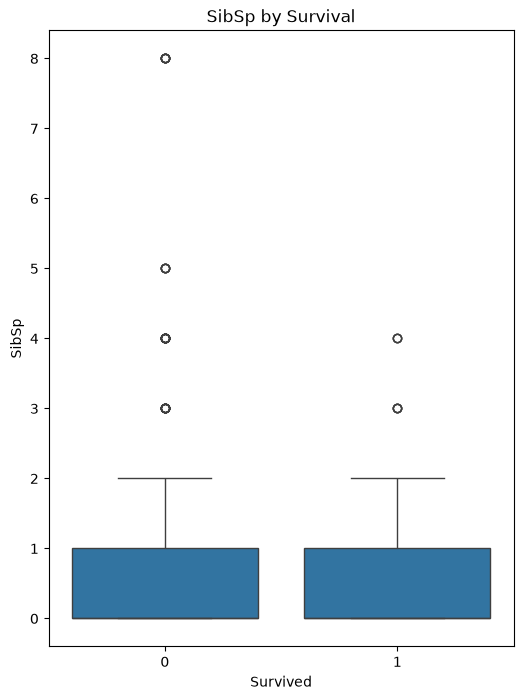

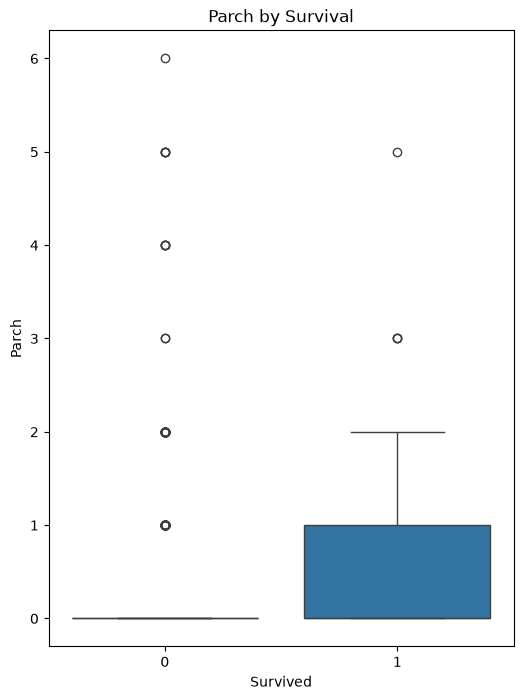

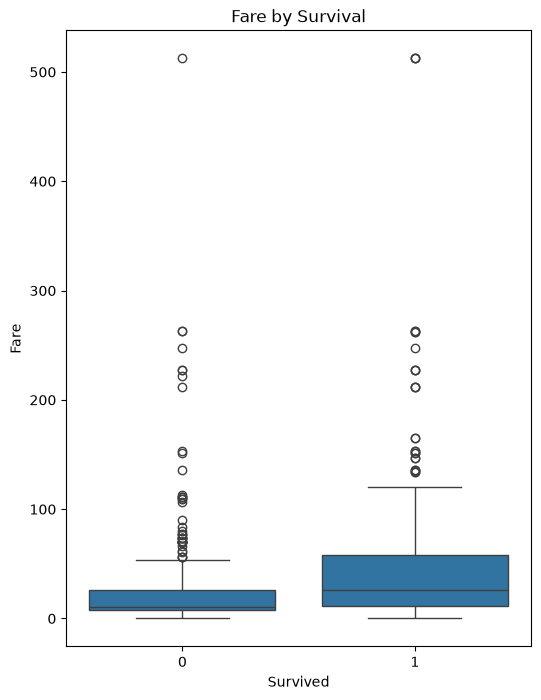

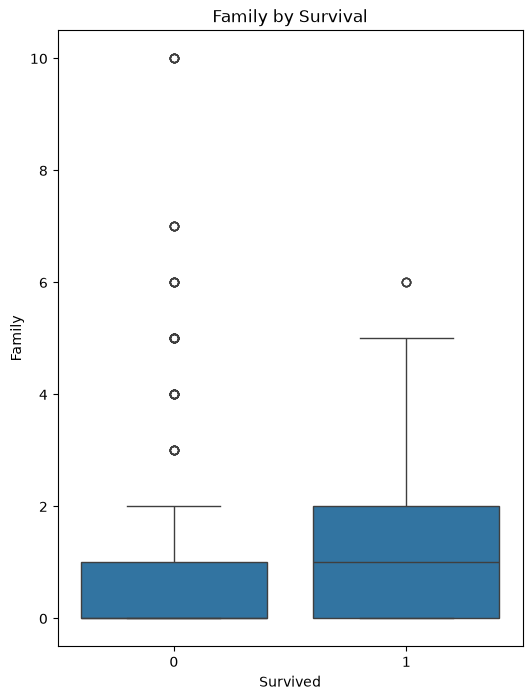

In [770]:
categorical=['Sex', 'Title', 'Pclass', 'Embarked', 'Cabin', 'Alone']
for column in categorical:
    plt.figure(figsize=(18,3))
    sns.countplot(data=df, x=column, hue='Survived')
    plt.title(f'Survived vs {column}')
    plt.xlabel(column)
    plt.ylabel('Number of passengers')
    plt.show()

for column in numeric:
    plt.figure(figsize=(6,8))
    sns.boxplot(data=df, x='Survived', y=column)

    plt.title(f'{column} by Survival')
    plt.xlabel('Survived')
    plt.ylabel(column)
    plt.show()